In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv(r"C:\Users\ARYAN\OneDrive\Desktop\Student Placement\Placement_Data_Full_Class_1.csv")
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [3]:
print("Shape:", df.shape)
print()
df.info()

Shape: (215, 15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


In [4]:
df.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [5]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check percentage columns are within valid 0-100 range
pct_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']
for c in pct_cols:
    print(f"{c}: min={df[c].min()}, max={df[c].max()}")

Duplicate rows: 0
ssc_p: min=40.89, max=89.4
hsc_p: min=37.0, max=97.7
degree_p: min=50.0, max=91.0
etest_p: min=50.0, max=98.0
mba_p: min=51.21, max=77.89


In [6]:
# Check categorical columns for inconsistent spelling/casing
cat_cols = ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation', 'status']
for c in cat_cols:
    print(f"{c}: {df[c].unique()}")

gender: ['M' 'F']
ssc_b: ['Others' 'Central']
hsc_b: ['Others' 'Central']
hsc_s: ['Commerce' 'Science' 'Arts']
degree_t: ['Sci&Tech' 'Comm&Mgmt' 'Others']
workex: ['No' 'Yes']
specialisation: ['Mkt&HR' 'Mkt&Fin']
status: ['Placed' 'Not Placed']


In [8]:
df.columns = df.columns.str.strip().str.lower()
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


Overall placement rate: 68.8%


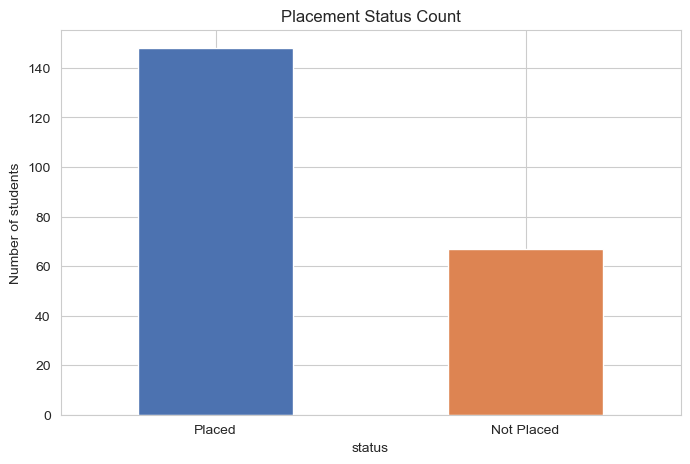

In [9]:
placement_rate = (df['status'] == 'Placed').mean() * 100
print(f"Overall placement rate: {placement_rate:.1f}%")

df['status'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title("Placement Status Count")
plt.ylabel("Number of students")
plt.xticks(rotation=0)
plt.show()

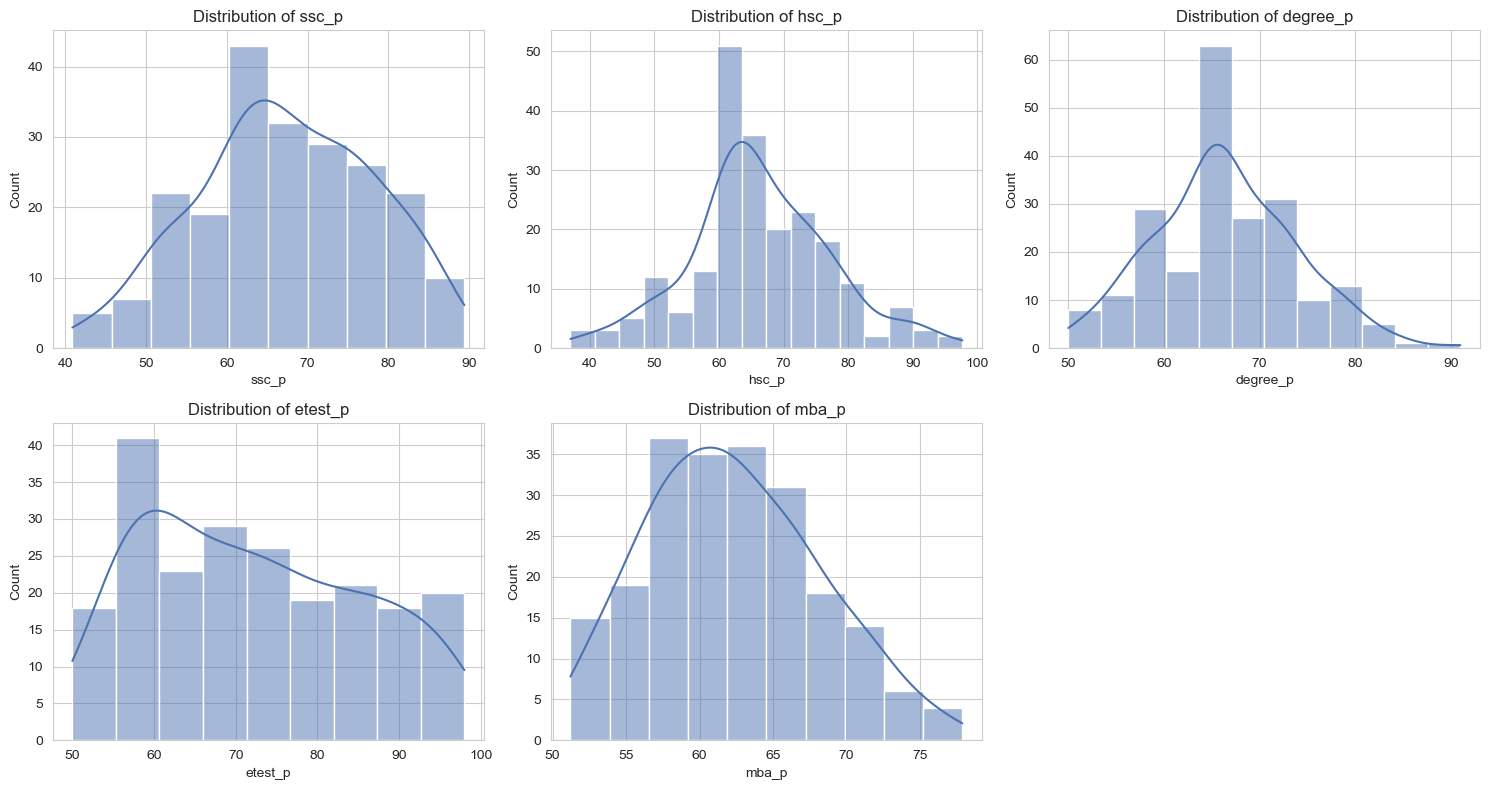

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
score_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']
for ax, col in zip(axes.flatten(), score_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f"Distribution of {col}")
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

specialisation
Mkt&Fin    79.2
Mkt&HR     55.8
Name: status, dtype: float64


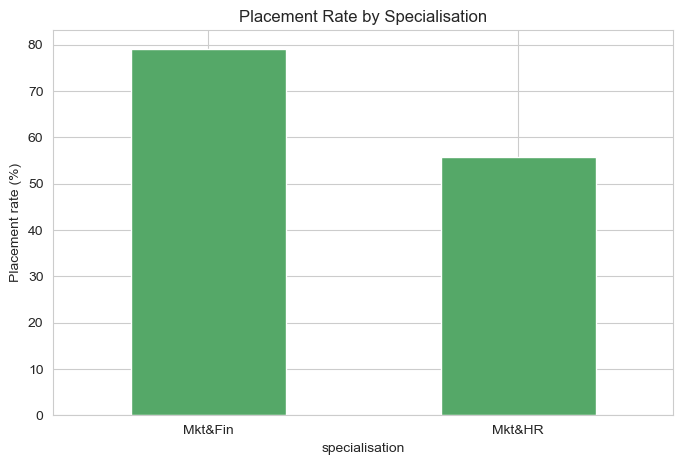

In [11]:
spec_rate = df.groupby('specialisation')['status'].apply(lambda x: (x == 'Placed').mean() * 100)
print(spec_rate.round(1))

spec_rate.plot(kind='bar', color='#55A868')
plt.title("Placement Rate by Specialisation")
plt.ylabel("Placement rate (%)")
plt.xticks(rotation=0)
plt.show()

gender
F    63.2
M    71.9
Name: status, dtype: float64


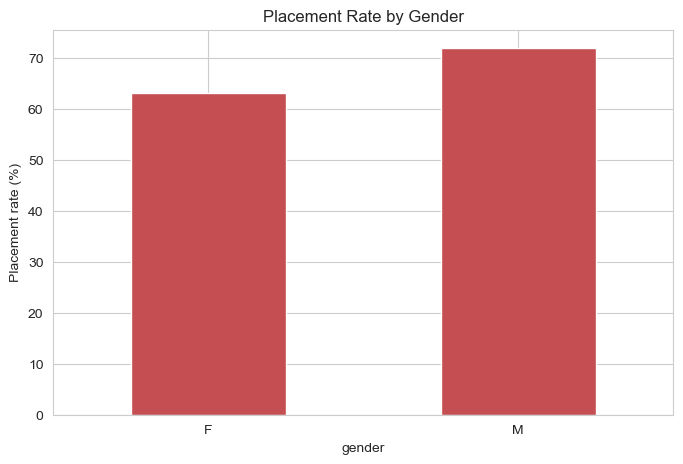

In [12]:
gender_rate = df.groupby('gender')['status'].apply(lambda x: (x == 'Placed').mean() * 100)
print(gender_rate.round(1))

gender_rate.plot(kind='bar', color='#C44E52')
plt.title("Placement Rate by Gender")
plt.ylabel("Placement rate (%)")
plt.xticks(rotation=0)
plt.show()

workex
No     59.6
Yes    86.5
Name: status, dtype: float64


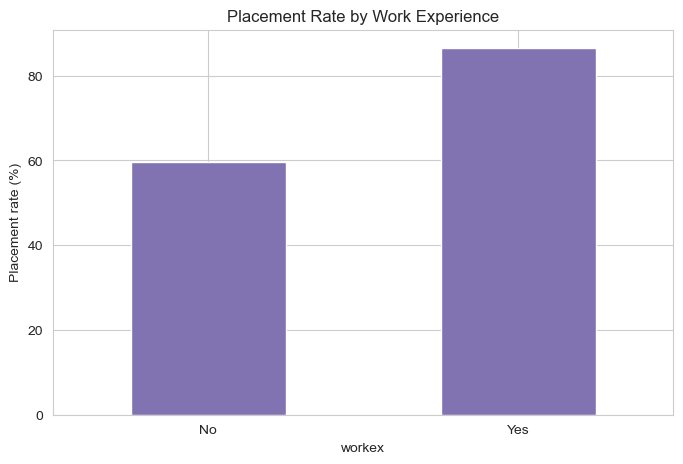

In [13]:
workex_rate = df.groupby('workex')['status'].apply(lambda x: (x == 'Placed').mean() * 100)
print(workex_rate.round(1))

workex_rate.plot(kind='bar', color='#8172B2')
plt.title("Placement Rate by Work Experience")
plt.ylabel("Placement rate (%)")
plt.xticks(rotation=0)
plt.show()

workex            No   Yes
specialisation            
Mkt&Fin         69.6  92.2
Mkt&HR          50.0  73.9


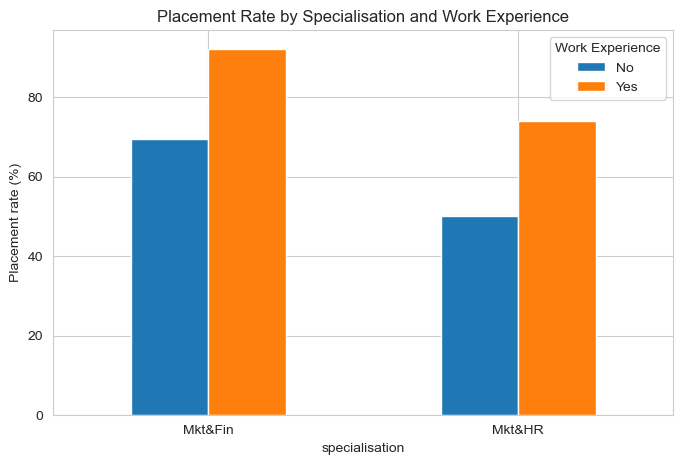

In [14]:
combo_rate = df.groupby(['specialisation', 'workex'])['status'].apply(lambda x: (x == 'Placed').mean() * 100).unstack()
print(combo_rate.round(1))

combo_rate.plot(kind='bar')
plt.title("Placement Rate by Specialisation and Work Experience")
plt.ylabel("Placement rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Work Experience")
plt.show()

In [15]:
board_rate = df.groupby('ssc_b')['status'].apply(lambda x: (x == 'Placed').mean() * 100)
print("10th board:")
print(board_rate.round(1))

board_rate_hsc = df.groupby('hsc_b')['status'].apply(lambda x: (x == 'Placed').mean() * 100)
print("\n12th board:")
print(board_rate_hsc.round(1))

10th board:
ssc_b
Central    67.2
Others     70.7
Name: status, dtype: float64

12th board:
hsc_b
Central    67.9
Others     69.5
Name: status, dtype: float64


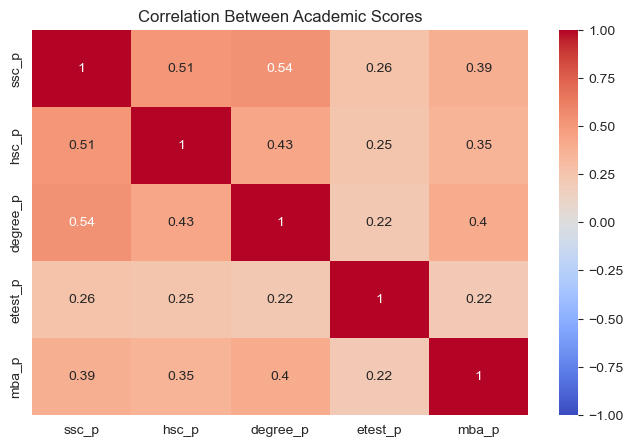

In [16]:
corr = df[score_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Between Academic Scores")
plt.show()

Salary stats (INR):
count       148.000000
mean     288655.405405
std       93457.452420
min      200000.000000
25%      240000.000000
50%      265000.000000
75%      300000.000000
max      940000.000000
Name: salary, dtype: float64


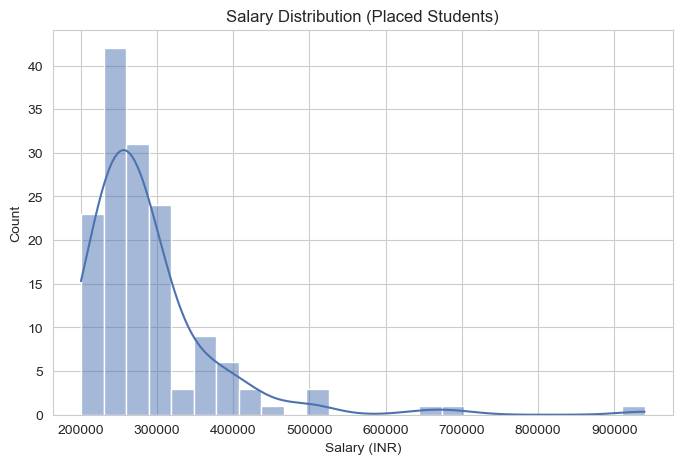

In [17]:
placed_df = df[df['status'] == 'Placed']

print("Salary stats (INR):")
print(placed_df['salary'].describe())

plt.figure()
sns.histplot(placed_df['salary'], kde=True, color='#4C72B0')
plt.title("Salary Distribution (Placed Students)")
plt.xlabel("Salary (INR)")
plt.show()

specialisation
Mkt&Fin    298853.0
Mkt&HR     270377.0
Name: salary, dtype: float64


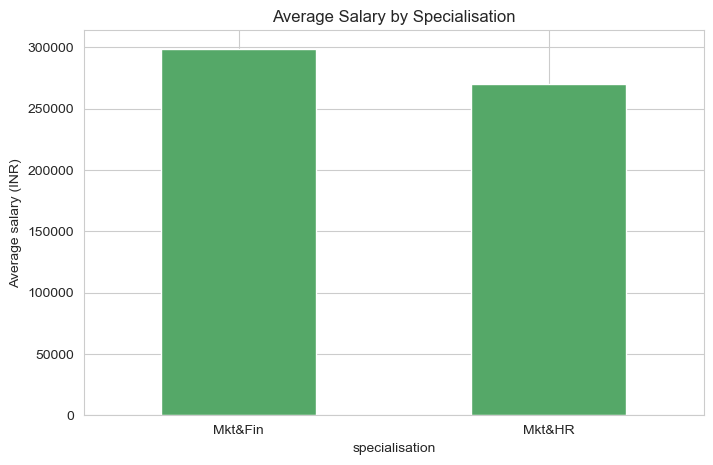

In [18]:
# Salary by specialisation
sal_by_spec = placed_df.groupby('specialisation')['salary'].mean()
print(sal_by_spec.round(0))

sal_by_spec.plot(kind='bar', color='#55A868')
plt.title("Average Salary by Specialisation")
plt.ylabel("Average salary (INR)")
plt.xticks(rotation=0)
plt.show()

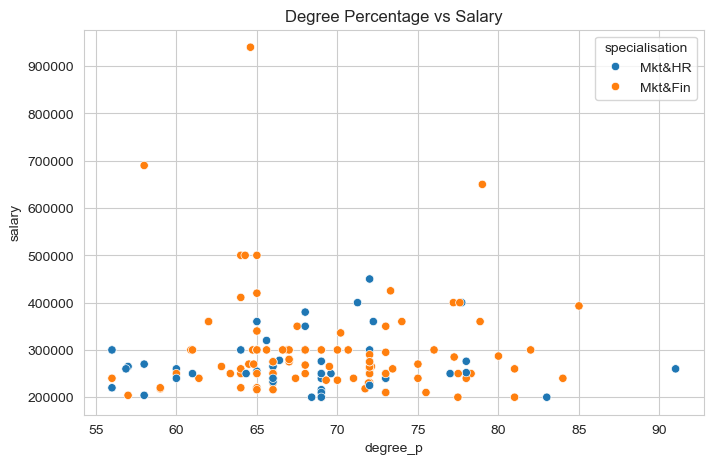

Correlation (degree_p vs salary): -0.019


In [19]:
# Does degree score correlate with salary among placed students?
plt.figure()
sns.scatterplot(data=placed_df, x='degree_p', y='salary', hue='specialisation')
plt.title("Degree Percentage vs Salary")
plt.show()

print("Correlation (degree_p vs salary):", placed_df['degree_p'].corr(placed_df['salary']).round(3))

In [20]:
contingency = pd.crosstab(df['specialisation'], df['status'])
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("=> Statistically significant relationship (p < 0.05)")
else:
    print("=> Not statistically significant (p >= 0.05)")

status          Not Placed  Placed
specialisation                    
Mkt&Fin                 25      95
Mkt&HR                  42      53

Chi-square statistic: 12.440
p-value: 0.0004
=> Statistically significant relationship (p < 0.05)


In [21]:
contingency2 = pd.crosstab(df['workex'], df['status'])
print(contingency2)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency2)
print(f"\nChi-square statistic: {chi2:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("=> Statistically significant relationship (p < 0.05)")
else:
    print("=> Not statistically significant (p >= 0.05)")

status  Not Placed  Placed
workex                    
No              57      84
Yes             10      64

Chi-square statistic: 15.154
p-value: 0.0001
=> Statistically significant relationship (p < 0.05)


In [22]:
contingency3 = pd.crosstab(df['gender'], df['status'])
print(contingency3)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency3)
print(f"\nChi-square statistic: {chi2:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("=> Statistically significant relationship (p < 0.05)")
else:
    print("=> Not statistically significant (p >= 0.05)")

status  Not Placed  Placed
gender                    
F               28      48
M               39     100

Chi-square statistic: 1.382
p-value: 0.2398
=> Not statistically significant (p >= 0.05)


In [23]:
mkt_fin_salary = placed_df[placed_df['specialisation'] == 'Mkt&Fin']['salary']
mkt_hr_salary = placed_df[placed_df['specialisation'] == 'Mkt&HR']['salary']

t_stat, p_value = stats.ttest_ind(mkt_fin_salary, mkt_hr_salary, equal_var=False)
print(f"Mkt&Fin mean salary: {mkt_fin_salary.mean():.0f}")
print(f"Mkt&HR mean salary: {mkt_hr_salary.mean():.0f}")
print(f"\nT-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("=> Statistically significant salary difference (p < 0.05)")
else:
    print("=> Not statistically significant (p >= 0.05) - could be due to small sample size")

Mkt&Fin mean salary: 298853
Mkt&HR mean salary: 270377

T-statistic: 2.123
p-value: 0.0354
=> Statistically significant salary difference (p < 0.05)


In [24]:
placed_scores = df[df['status'] == 'Placed']['degree_p']
not_placed_scores = df[df['status'] == 'Not Placed']['degree_p']

t_stat, p_value = stats.ttest_ind(placed_scores, not_placed_scores, equal_var=False)
print(f"Placed mean degree_p: {placed_scores.mean():.2f}")
print(f"Not Placed mean degree_p: {not_placed_scores.mean():.2f}")
print(f"\nT-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("=> Statistically significant difference (p < 0.05)")
else:
    print("=> Not statistically significant (p >= 0.05)")

Placed mean degree_p: 68.74
Not Placed mean degree_p: 61.13

T-statistic: 8.054
p-value: 0.0000
=> Statistically significant difference (p < 0.05)


5. Key Findings Summary

1. Overall placement rate: 68.8% of students in this dataset were placed.

2. Work experience effect (statistically significant): Students with prior work experience had an 86.5% placement rate vs 59.6% for those without (p = 0.0001, well below 0.05). This is a real, reliable pattern — not noise.

3. Specialisation effect (statistically significant): Mkt&Fin students had a 79.2% placement rate vs 55.8% for Mkt&HR students (p = 0.00042). This is a strong, statistically real gap.

4. Salary gap by specialisation (statistically significant): Mkt&Fin placed students earned ₹298,853 on average vs ₹270,377 for Mkt&HR (p = 0.035, just under the 0.05 threshold — significant, but less strongly so than the placement-rate gap above).

5. Academic score relationship (statistically significant): Placed students had a notably higher average degree score (68.74%) than students who were not placed (61.13%), with a p-value effectively at 0.0 (far below 0.05). Degree performance is a genuinely strong predictor of placement in this dataset.

6. Gender gap (NOT statistically significant): Men had a 71.9% placement rate vs 63.2% for women, but the p-value is 0.24 — well above the 0.05 threshold. With only 215 students, this gap is small enough that it could plausibly be due to random variation rather than a real, systematic effect. Report this honestly on your dashboard: the raw numbers show a gap, but statistically we cannot confidently say it is real.

Overall takeaway for your dashboard headline stats: work experience, specialisation, and degree score are the three factors with the strongest, statistically defensible relationships to placement outcome in this dataset. Gender shows a raw difference but is not statistically confirmed — worth stating clearly and carefully.
